# **Statistics - Final Project**
# **Nadav Salonikio | Nevo Ravel**

# Data Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import os
FIG_DIR = "/content/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    """Call immediately before plt.show()."""
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=200, bbox_inches="tight")

# Please upload the data first!
DATA_PATH     = "/content/global-data-on-sustainable-energy.csv"
OUT_PATH      = "/content/sustainable_energy_cleaned.csv"
FIRST_YEAR    = 2000
SNAPSHOT_YEAR = 2019      #  2020 to be dropped completely: reporting is very partial (Covid)
N_CLUSTERS    = 4
SEED          = 42

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.width", 140, "display.max_columns", 40)

df = pd.read_csv(DATA_PATH)

# Filter the year range.
df = df[df["Year"].between(FIRST_YEAR, SNAPSHOT_YEAR)].copy()
print(df.shape)

(3474, 21)


In [2]:
# Changing column names to readable names.
df = df.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Access to electricity (% of population)": "electricity_access_pct",
    "Access to clean fuels for cooking": "clean_cooking_fuel_pct",
    "Renewable-electricity-generating-capacity-per-capita": "renewable_capacity_per_capita",
    "Financial flows to developing countries (US $)": "financial_flows_usd",
    "Renewable energy share in the total final energy consumption (%)": "renewable_share_pct",
    "Electricity from fossil fuels (TWh)": "elec_fossil_twh",
    "Electricity from nuclear (TWh)": "elec_nuclear_twh",
    "Electricity from renewables (TWh)": "elec_renewables_twh",
    "Low-carbon electricity (% electricity)": "low_carbon_elec_pct",
    "Primary energy consumption per capita (kWh/person)": "energy_consumption_per_capita_kwh",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": "energy_intensity",
    "Value_co2_emissions_kt_by_country": "co2_emissions_kt",
    "Renewables (% equivalent primary energy)": "renewables_equiv_primary_energy_pct",
    "gdp_growth": "gdp_growth_pct",
    "gdp_per_capita": "gdp_per_capita_usd",
    "Density\\n(P/Km2)": "population_density",
    "Land Area(Km2)": "land_area_km2",
    "Latitude": "latitude",
    "Longitude": "longitude",
})

In [3]:
# Conversions and calculation of derived variables

# Cleaning the population density column
df["population_density"] = df["population_density"].astype(str).str.replace(",", "", regex=False).astype(float)

# Calculating the population estimate and emissions per capita
df["population_static"]        = df["population_density"] * df["land_area_km2"]
df["co2_per_capita_static_t"]  = df["co2_emissions_kt"] * 1000 / df["population_static"]

# Calculating total electricity production and its three components—fossil, nuclear, and renewable—as a percentage
df["total_elec_twh"] = df["elec_fossil_twh"] + df["elec_nuclear_twh"] + df["elec_renewables_twh"]
df.loc[df["total_elec_twh"] <= 0, "total_elec_twh"] = np.nan

df["fossil_share_of_elec_pct"]     = df["elec_fossil_twh"]     / df["total_elec_twh"] * 100
df["nuclear_share_of_elec_pct"]    = df["elec_nuclear_twh"]    / df["total_elec_twh"] * 100
df["renewables_share_of_elec_pct"] = df["elec_renewables_twh"] / df["total_elec_twh"] * 100

In [4]:
# Mapping each country to a continent. Used for regional comparisons in Stage 1
# and as a grouping variable in Stage 3.
continents = {
    "Africa": ["Algeria", "Angola", "Benin", "Botswana", "Burkina Faso", "Burundi", "Cameroon",
               "Central African Republic", "Chad", "Comoros", "Congo", "Djibouti", "Egypt",
               "Equatorial Guinea", "Eritrea", "Eswatini", "Ethiopia", "Gabon", "Gambia", "Ghana",
               "Guinea", "Guinea-Bissau", "Kenya", "Lesotho", "Liberia", "Libya", "Madagascar",
               "Malawi", "Mali", "Mauritania", "Mauritius", "Morocco", "Mozambique", "Namibia",
               "Niger", "Nigeria", "Rwanda", "Sao Tome and Principe", "Senegal", "Seychelles",
               "Sierra Leone", "Somalia", "South Africa", "South Sudan", "Sudan", "Togo",
               "Tunisia", "Uganda", "Zambia", "Zimbabwe"],
    "Asia": ["Afghanistan", "Armenia", "Azerbaijan", "Bahrain", "Bangladesh", "Bhutan", "Cambodia",
             "China", "Georgia", "India", "Indonesia", "Iraq", "Israel", "Japan", "Jordan",
             "Kazakhstan", "Kuwait", "Kyrgyzstan", "Lebanon", "Malaysia", "Maldives", "Mongolia",
             "Myanmar", "Nepal", "Oman", "Pakistan", "Philippines", "Qatar", "Saudi Arabia",
             "Singapore", "Sri Lanka", "Tajikistan", "Thailand", "Turkey", "Turkmenistan",
             "United Arab Emirates", "Uzbekistan", "Yemen"],
    "Europe": ["Albania", "Austria", "Belarus", "Belgium", "Bosnia and Herzegovina", "Bulgaria",
               "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia", "Finland", "France",
               "Germany", "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Latvia",
               "Lithuania", "Luxembourg", "Malta", "Montenegro", "Netherlands", "North Macedonia",
               "Norway", "Poland", "Portugal", "Romania", "Serbia", "Slovakia", "Slovenia",
               "Spain", "Sweden", "Switzerland", "Ukraine", "United Kingdom"],
    "North America": ["Antigua and Barbuda", "Aruba", "Bahamas", "Barbados", "Belize", "Bermuda",
                      "Canada", "Cayman Islands", "Costa Rica", "Cuba", "Dominica",
                      "Dominican Republic", "El Salvador", "Grenada", "Guatemala", "Haiti",
                      "Honduras", "Jamaica", "Mexico", "Nicaragua", "Panama", "Puerto Rico",
                      "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines",
                      "Trinidad and Tobago", "United States"],  # includes Central America and the Caribbean
    "Oceania": ["Australia", "Fiji", "Kiribati", "Nauru", "New Caledonia", "New Zealand",
                "Papua New Guinea", "Samoa", "Solomon Islands", "Tonga", "Tuvalu", "Vanuatu"],
    "South America": ["Argentina", "Brazil", "Chile", "Colombia", "Ecuador", "French Guiana",
                      "Guyana", "Paraguay", "Peru", "Suriname", "Uruguay"],
}

# Flatten the lists into one country -> continent dictionary
continent_map = {}
for continent, country_list in continents.items():
    for country in country_list:
        continent_map[country] = continent

df["continent"] = df["country"].map(continent_map)

CONTINENT_ORDER = list(continents)
PALETTE = dict(zip(CONTINENT_ORDER, sns.color_palette("colorblind", len(CONTINENT_ORDER))))

missing = sorted(df.loc[df["continent"].isna(), "country"].unique())
print(f"Countries without a continent: {len(missing)}", missing[:10])

Countries without a continent: 0 []


In [5]:
# Sanity checks
print("Sanity Checks")

# The population estimate is constant over time, so it cannot support time trends per capita.
n_pop = df.groupby("country")["population_static"].nunique().max()
print(f"[1] Distinct population values per country (max): {n_pop}")
if n_pop == 1:
    print("    -> static, do not use for time trends")
else:
    print("    -> varies over time")

# Fossil and low-carbon shares add up to exactly 100, so both must not enter the same model or cluster.
gap = (df["fossil_share_of_elec_pct"] + df["low_carbon_elec_pct"] - 100).abs().max()
print(f"[2] Largest deviation of fossil + low_carbon from 100: {gap:.2e}")
if gap < 0.001:
    print("    -> mirror images, do not use both together")
else:
    print("    -> independent")

# Emissions reporting is partial, so every aggregate is a sample total and not a world total.
reporting = df.groupby("year")["co2_emissions_kt"].count()
n_countries = df["country"].nunique()
print(f"[3] Countries reporting emissions per year: {reporting.min()}-{reporting.max()} out of {n_countries}")
print("    -> aggregates are sample totals, not world totals")

Sanity Checks
[1] Distinct population values per country (max): 1
    -> static, do not use for time trends
[2] Largest deviation of fossil + low_carbon from 100: 1.31e-05
    -> mirror images, do not use both together
[3] Countries reporting emissions per year: 159-163 out of 176
    -> aggregates are sample totals, not world totals


In [6]:
# Save the cleaned dataset

df.to_csv(OUT_PATH, index=False)

print("Cleaned dataset saved:", OUT_PATH)
print("Shape:", df.shape)
print("\nCountries per continent:")
print(df.drop_duplicates("country")["continent"].value_counts())


Cleaned dataset saved: /content/sustainable_energy_cleaned.csv
Shape: (3474, 28)

Countries per continent:
continent
Africa           50
Asia             38
Europe           38
North America    27
Oceania          12
South America    11
Name: count, dtype: int64


## STAGE 1 - Exploratory Data Analysis (EDA)

In [7]:
# The opening puzzle: same renewable share, opposite worlds.
snap = df[df["year"] == SNAPSHOT_YEAR]
rank = snap["renewable_share_pct"].rank(ascending=False)
n_ranked = rank.notna().sum()

rows = [("Renewable share of final energy (%)", "renewable_share_pct",     "{:.1f}"),
        ("Access to clean cooking fuel (%)",    "clean_cooking_fuel_pct",  "{:.1f}"),
        ("Access to electricity (%)",           "electricity_access_pct",  "{:.1f}"),
        ("CO2 per capita (tons)",               "co2_per_capita_static_t", "{:.2f}"),
        ("GDP per capita (US$)",                "gdp_per_capita_usd",      "{:,.0f}")]

print(f"=== The opening puzzle: same metric, opposite worlds ({SNAPSHOT_YEAR}) ===")
print(" " * 38 + "".join(c.rjust(12) for c in ["Somalia", "Iceland"]))
for label, col, fmt in rows:
    print(label.ljust(38) + "".join(
        fmt.format(snap.loc[snap["country"] == c, col].iloc[0]).rjust(12)
        for c in ["Somalia", "Iceland"]))
print("Rank by renewable share".ljust(38) + "".join(
    "#{} of {}".format(int(rank[snap["country"] == c].iloc[0]), n_ranked).rjust(12)
    for c in ["Somalia", "Iceland"]))



=== The opening puzzle: same metric, opposite worlds (2019) ===
                                           Somalia     Iceland
Renewable share of final energy (%)           95.0        81.1
Access to clean cooking fuel (%)               2.9       100.0
Access to electricity (%)                     49.2       100.0
CO2 per capita (tons)                         0.04        5.31
GDP per capita (US$)                           419      68,941
Rank by renewable share                  #1 of 174  #14 of 174


In [8]:
# Is Somalia an outlier, or is the pattern general?
TOP_N, CLEAN_COOKING_CUTOFF = 15, 15

top_renew = (snap.dropna(subset=["renewable_share_pct", "clean_cooking_fuel_pct"])
             .nlargest(TOP_N, "renewable_share_pct"))
n_low = (top_renew["clean_cooking_fuel_pct"] < CLEAN_COOKING_CUTOFF).sum()

print(f"=== Top {TOP_N} countries by renewable share ({SNAPSHOT_YEAR}) ===")
print(top_renew[["country", "renewable_share_pct", "clean_cooking_fuel_pct"]]
      .rename(columns={"country": "Country",
                       "renewable_share_pct": "Renewable share %",
                       "clean_cooking_fuel_pct": "Clean cooking %"})
      .round(1).to_string(index=False))
print(f"\n{n_low} of the top {TOP_N} have clean cooking access below {CLEAN_COOKING_CUTOFF}%.")
print("So the Somalia case is not a cherry-picked outlier: most of the countries that")
print("score highest on 'renewable energy' are countries where people still cook on fire.")

=== Top 15 countries by renewable share (2019) ===
                 Country  Renewable share %  Clean cooking %
                 Somalia               95.0              2.9
Central African Republic               91.3              0.7
                  Uganda               90.2              0.5
                   Gabon               89.9             87.8
                Ethiopia               88.9              7.0
                 Liberia               87.2              0.4
           Guinea-Bissau               86.2              1.0
                 Burundi               84.8              0.2
                  Zambia               84.5             11.2
              Madagascar               82.8              0.9
                  Bhutan               82.3             79.4
                Zimbabwe               81.5             30.1
                 Nigeria               81.4             12.9
                 Iceland               81.1            100.0
                   Niger          

In [9]:
# ==========================================
# DESCRIPTIVE STATISTICS TABLES
# ==========================================

# Table 1: mean, standard deviation, min, max and quartiles for nine key variables,
# over all country-year pairs.

desc_vars = [
    "electricity_access_pct", "clean_cooking_fuel_pct", "renewable_share_pct",
    "low_carbon_elec_pct", "energy_consumption_per_capita_kwh", "energy_intensity",
    "gdp_growth_pct", "gdp_per_capita_usd", "co2_emissions_kt",
]
desc = df[desc_vars].describe().T
desc.insert(0, "missing_%", (df[desc_vars].isna().mean() * 100).round(1))
print(f"=== Table 1: Descriptive statistics, {FIRST_YEAR}-{SNAPSHOT_YEAR} ===")
print(desc.round(2))

=== Table 1: Descriptive statistics, 2000-2019 ===
                                   missing_%   count       mean        std     min      25%       50%       75%          max
electricity_access_pct                   0.3  3464.0      78.60      30.50    1.25    58.26     98.10    100.00       100.00
clean_cooking_fuel_pct                   4.6  3313.0      63.04      39.11    0.00    22.50     82.90    100.00       100.00
renewable_share_pct                      0.6  3454.0      32.62      29.89    0.00     6.51     23.28     55.22        96.04
low_carbon_elec_pct                      1.2  3434.0      36.62      34.36    0.00     2.40     27.62     64.15       100.00
energy_consumption_per_capita_kwh        0.0  3474.0   25827.91   34923.40    0.00  3116.44  13118.84  34035.50    262585.70
energy_intensity                         0.9  3441.0       5.31       3.53    0.11     3.17      4.30      6.02        32.57
gdp_growth_pct                           8.7  3173.0       3.84       5.30

In [10]:
# Table 2: cross-country mean of each variable in the first and the last year,
# and the change between them. A first quantitative look at the direction of the trends.

trend_vars = ["electricity_access_pct", "clean_cooking_fuel_pct", "renewable_share_pct",
              "low_carbon_elec_pct", "energy_consumption_per_capita_kwh",
              "energy_intensity", "gdp_growth_pct", "gdp_per_capita_usd"]

two_years = df[df["year"].isin([FIRST_YEAR, SNAPSHOT_YEAR])]
trend_tab = two_years.groupby("year")[trend_vars].mean().T
trend_tab["change"] = trend_tab[SNAPSHOT_YEAR] - trend_tab[FIRST_YEAR]
trend_tab.columns = [f"mean_{FIRST_YEAR}", f"mean_{SNAPSHOT_YEAR}", "change"]

print(f"=== Table 2: {FIRST_YEAR} vs {SNAPSHOT_YEAR} (cross-country mean) ===")
print(trend_tab.round(2))

=== Table 2: 2000 vs 2019 (cross-country mean) ===
                                   mean_2000  mean_2019   change
electricity_access_pct                 73.12      84.76    11.64
clean_cooking_fuel_pct                 58.06      67.19     9.12
renewable_share_pct                    34.49      31.29    -3.19
low_carbon_elec_pct                    36.63      39.01     2.38
energy_consumption_per_capita_kwh   24297.36   25911.04  1613.68
energy_intensity                        6.28       4.53    -1.76
gdp_growth_pct                          4.30       2.87    -1.43
gdp_per_capita_usd                   7364.89   16176.65  8811.76


In [11]:
# Table 3: Emissions per capita in 2019

snap_df = df[df["year"] == SNAPSHOT_YEAR].copy()
print(f"\n=== Table 3: Emissions per capita, {SNAPSHOT_YEAR} cross-section only ===")
print(snap_df["co2_per_capita_static_t"].describe().round(2).to_string())


=== Table 3: Emissions per capita, 2019 cross-section only ===
count    159.00
mean       4.02
std        4.75
min        0.04
25%        0.75
50%        2.54
75%        5.41
max       32.01


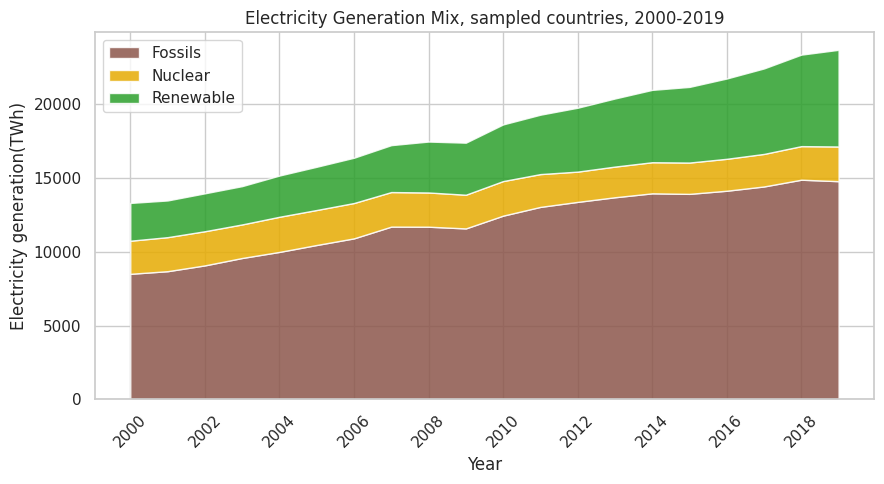

The share of fossil fuels in electricity production: 63.9% -> 62.4%
Generation growth 2000-2019: fossil x1.74 | nuclear x1.05 | renewables x2.56
The share of nuclear in electricity production: 16.9% -> 9.9%


In [12]:
# ==========================================
# 3. VISUALIZATIONS (EDA)
# ==========================================

# V1: Electricity generation mix over time
mix = df.groupby("year")[["elec_fossil_twh", "elec_nuclear_twh", "elec_renewables_twh"]].sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(mix.index, mix["elec_fossil_twh"], mix["elec_nuclear_twh"], mix["elec_renewables_twh"],
             labels=["Fossils", "Nuclear", "Renewable"],
             colors=["#8c564b", "#e6ab02", "#2ca02c"], alpha=0.85)
ax.set(xlabel="Year", ylabel="Electricity generation(TWh)",
       title=f"Electricity Generation Mix, sampled countries, {FIRST_YEAR}-{SNAPSHOT_YEAR}")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.xticks(rotation=45); plt.tight_layout();
save_fig("v1_generation_mix")
plt.show()

fossil_start = mix.loc[FIRST_YEAR, "elec_fossil_twh"] / mix.loc[FIRST_YEAR].sum() * 100
fossil_end   = mix.loc[SNAPSHOT_YEAR, "elec_fossil_twh"] / mix.loc[SNAPSHOT_YEAR].sum() * 100
print(f"The share of fossil fuels in electricity production: {fossil_start:.1f}% -> {fossil_end:.1f}%")

growth = mix.loc[SNAPSHOT_YEAR] / mix.loc[FIRST_YEAR]
print(f"Generation growth {FIRST_YEAR}-{SNAPSHOT_YEAR}: "
      f"fossil x{growth['elec_fossil_twh']:.2f} | "
      f"nuclear x{growth['elec_nuclear_twh']:.2f} | "
      f"renewables x{growth['elec_renewables_twh']:.2f}")

nuc_start = mix.loc[FIRST_YEAR, "elec_nuclear_twh"] / mix.loc[FIRST_YEAR].sum() * 100
nuc_end   = mix.loc[SNAPSHOT_YEAR, "elec_nuclear_twh"] / mix.loc[SNAPSHOT_YEAR].sum() * 100
print(f"The share of nuclear in electricity production: {nuc_start:.1f}% -> {nuc_end:.1f}%")

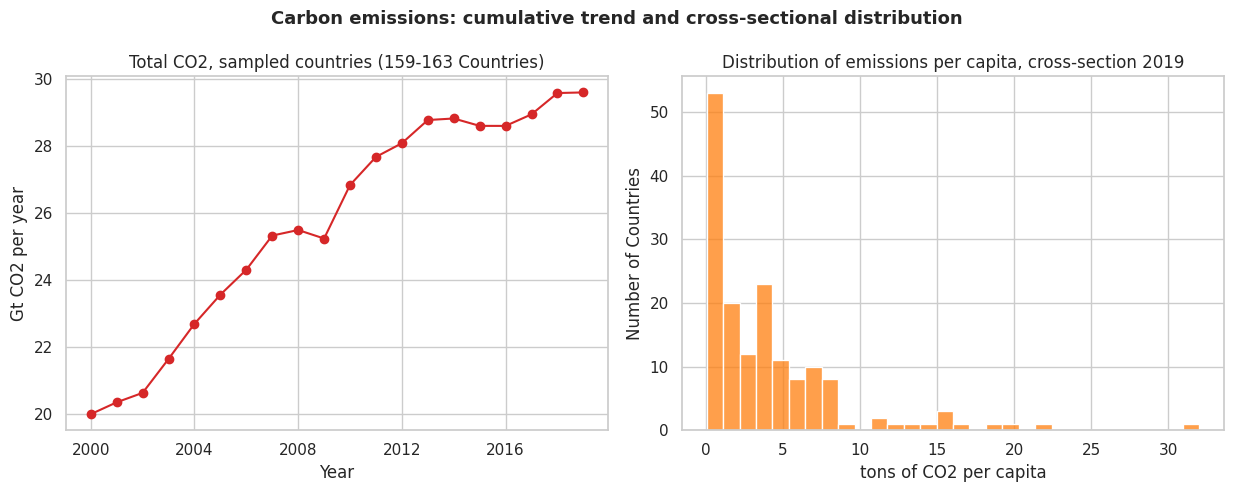

Total sample emissions: 20.0 Gt -> 29.6 Gt (48%)


In [13]:
# V2: CO2 emissions: world total (sum) and average per-capita (mean)

co2_total = df.groupby("year")["co2_emissions_kt"].sum() / 1e6      # Gt
n_report  = df.groupby("year")["co2_emissions_kt"].count()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

axes[0].plot(co2_total.index, co2_total.values, marker="o", color="#d62728")
axes[0].set(xlabel="Year", ylabel="Gt CO2 per year",
            title=f"Total CO2, sampled countries ({n_report.min()}-{n_report.max()} Countries)")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(4))

sns.histplot(snap_df["co2_per_capita_static_t"].dropna(), bins=30, ax=axes[1], color="#ff7f0e")
axes[1].set(xlabel="tons of CO2 per capita", ylabel="Number of Countries",
            title=f"Distribution of emissions per capita, cross-section {SNAPSHOT_YEAR}")

fig.suptitle("Carbon emissions: cumulative trend and cross-sectional distribution", fontweight="bold", fontsize=13)
plt.tight_layout();
save_fig("v2_emissions")
plt.show()

print(f"Total sample emissions: {co2_total.iloc[0]:.1f} Gt -> {co2_total.iloc[-1]:.1f} Gt "
      f"({(co2_total.iloc[-1]/co2_total.iloc[0]-1)*100:.0f}%)")

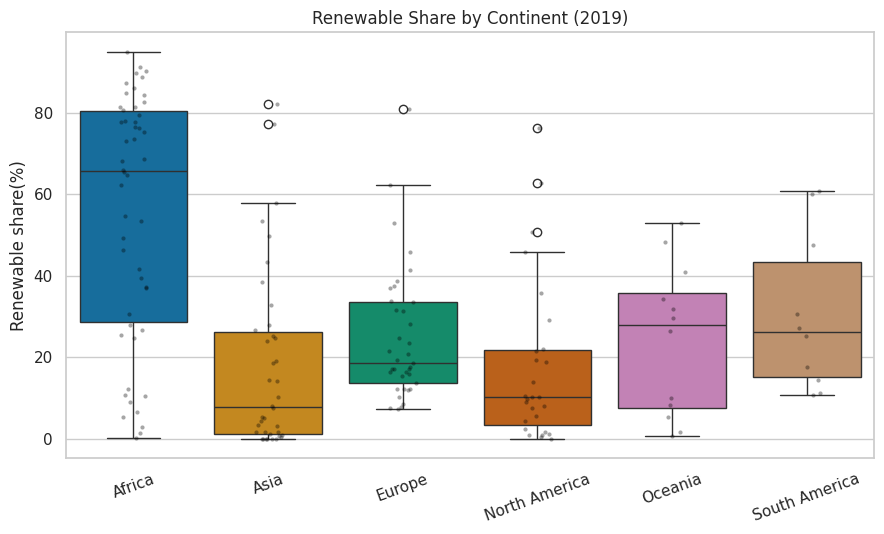

In [14]:
# V3: Renewable share by continent

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=snap_df, x="continent", y="renewable_share_pct", order=CONTINENT_ORDER,
            hue="continent", palette=PALETTE, legend=False, ax=ax)
sns.stripplot(data=snap_df, x="continent", y="renewable_share_pct", order=CONTINENT_ORDER,
              color="black", alpha=0.35, size=3, ax=ax)
ax.set(xlabel="", ylabel="Renewable share(%)",
       title=f"Renewable Share by Continent ({SNAPSHOT_YEAR})")
plt.xticks(rotation=20); plt.tight_layout();
save_fig("v3_renewable_by_continent")
plt.show()

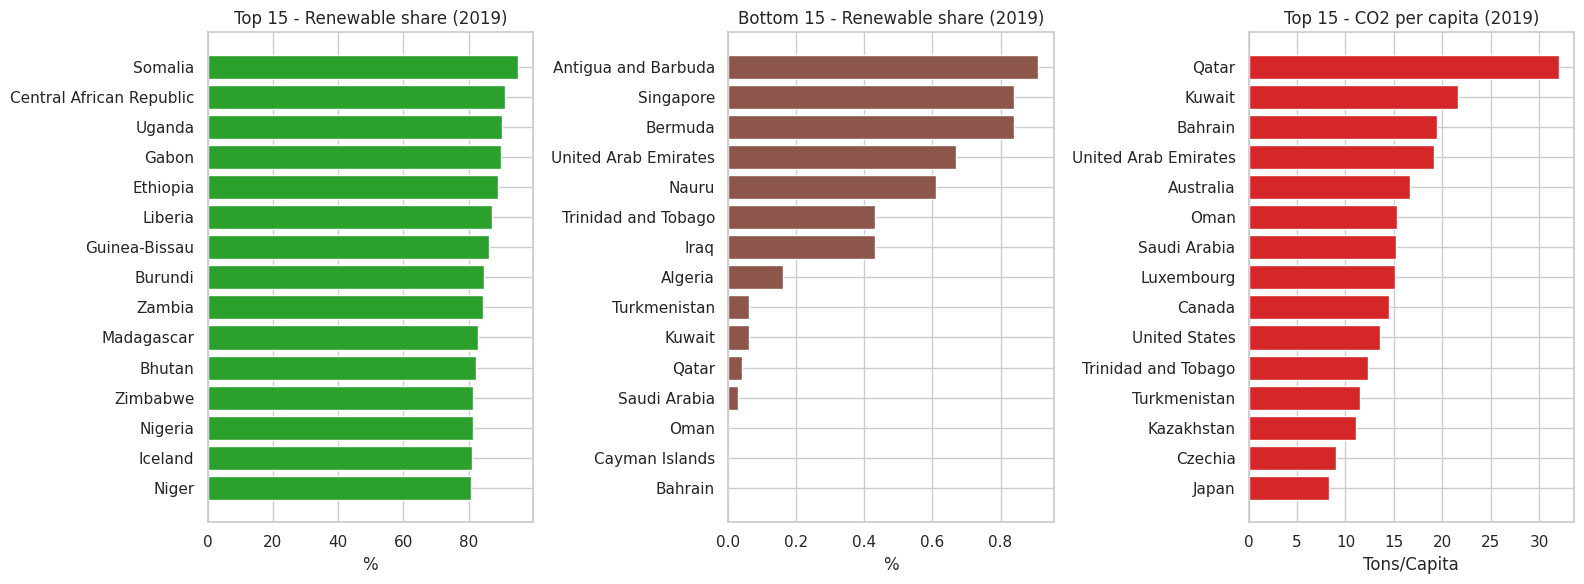

In [15]:
# V4: Top + bottom 15 countries by renewable share
# V5: Top 15 countries by CO2 emissions per capita

by_renewable = snap_df.dropna(subset=["renewable_share_pct"])
top_renewable    = by_renewable.nlargest(15, "renewable_share_pct").sort_values("renewable_share_pct")
bottom_renewable = by_renewable.nsmallest(15, "renewable_share_pct").sort_values("renewable_share_pct")

by_co2  = snap_df.dropna(subset=["co2_per_capita_static_t"])
top_co2 = by_co2.nlargest(15, "co2_per_capita_static_t").sort_values("co2_per_capita_static_t")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].barh(top_renewable["country"], top_renewable["renewable_share_pct"], color="#2ca02c")
axes[0].set(title=f"Top 15 - Renewable share ({SNAPSHOT_YEAR})", xlabel="%")
axes[1].barh(bottom_renewable["country"], bottom_renewable["renewable_share_pct"], color="#8c564b")
axes[1].set(title=f"Bottom 15 - Renewable share ({SNAPSHOT_YEAR})", xlabel="%")
axes[2].barh(top_co2["country"], top_co2["co2_per_capita_static_t"], color="#d62728")
axes[2].set(title=f"Top 15 - CO2 per capita ({SNAPSHOT_YEAR})", xlabel="Tons/Capita")
plt.tight_layout()
save_fig("v4_v5_rankings")
plt.show()

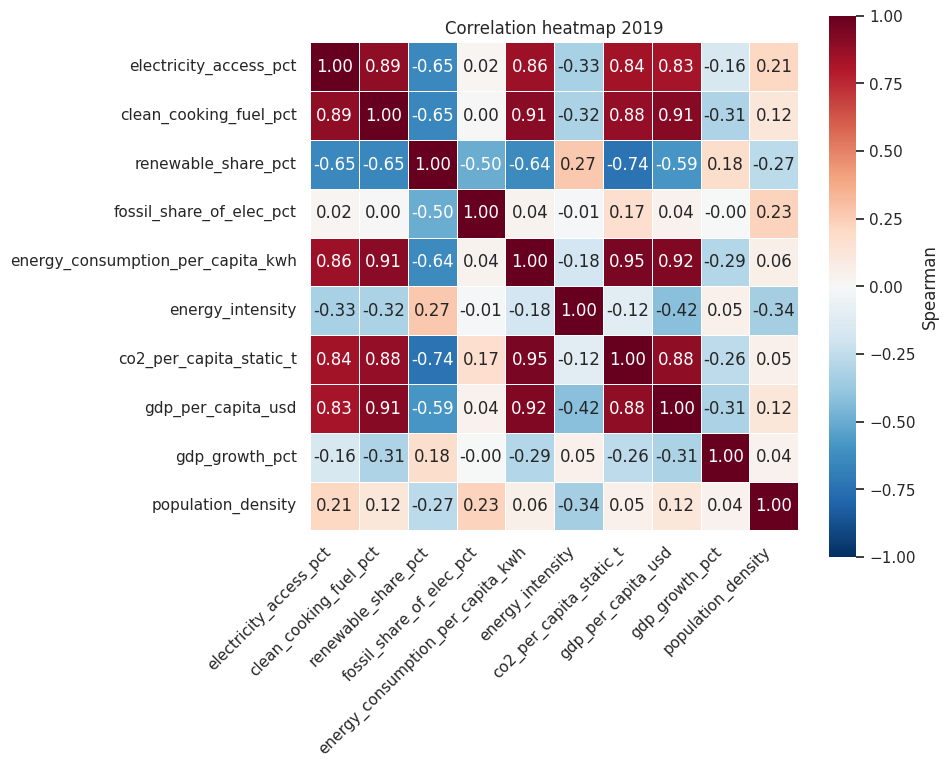

In [16]:
# V6: Correlation heatmap of key numeric variables
corr_vars = ["electricity_access_pct", "clean_cooking_fuel_pct", "renewable_share_pct",
             "fossil_share_of_elec_pct", "energy_consumption_per_capita_kwh", "energy_intensity",
             "co2_per_capita_static_t", "gdp_per_capita_usd", "gdp_growth_pct", "population_density"]

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(snap_df[corr_vars].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "Spearman"}, ax=ax)
ax.set_title(f"Correlation heatmap {SNAPSHOT_YEAR}")
plt.xticks(rotation=45, ha="right"); plt.tight_layout();
save_fig("v6_correlation_heatmap")
plt.show()

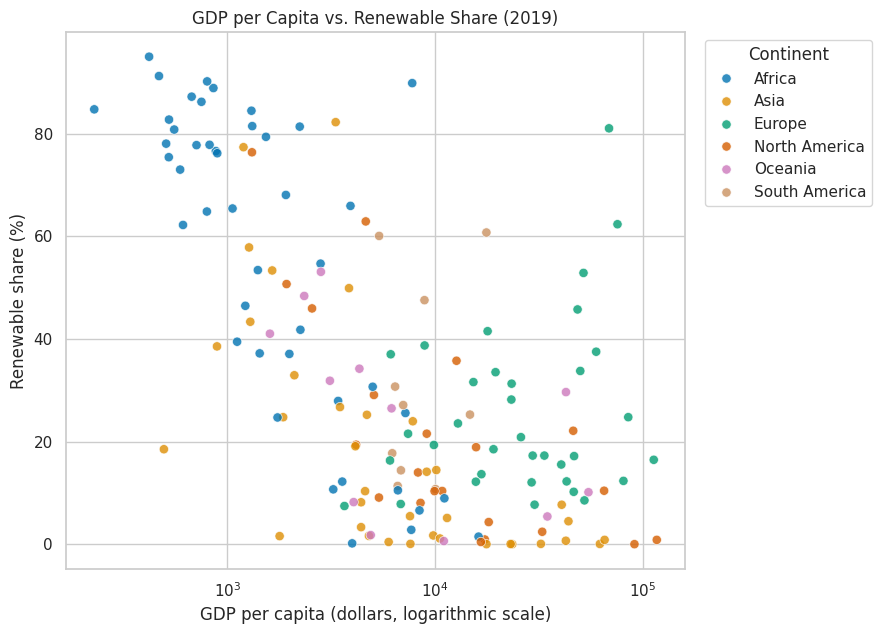

In [17]:
# V7: GDP per capita vs renewable share, colored by continent
plot_df = snap_df.dropna(subset=["gdp_per_capita_usd", "renewable_share_pct"])

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.scatterplot(data=plot_df, x="gdp_per_capita_usd", y="renewable_share_pct",
                hue="continent", hue_order=CONTINENT_ORDER, palette=PALETTE,
                s=45, alpha=0.8, ax=ax)
ax.set_xscale("log")
ax.set(xlabel="GDP per capita (dollars, logarithmic scale)", ylabel="Renewable share (%)",
       title=f"GDP per Capita vs. Renewable Share ({SNAPSHOT_YEAR})")
ax.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_fig("v7_gdp_vs_renewable")
plt.show()

# STAGE 2 - EFFECTS OF ENERGY TYPES ON OUTCOMES

In [18]:
# Helper functions for presenting the models' results

def fit_panel(formula, data):
    # OLS on the panel, with country and year fixed effects.
    # Standard errors are clustered by country, needed with about 20 observations per country.
    formula = formula + " + C(country) + C(year)"
    return smf.ols(formula, data=data).fit(cov_type="cluster",
                                           cov_kwds={"groups": data["country"]})

def tidy(model, title=""):
    # Readable coefficient table, without the hundreds of fixed-effect dummies.
    ci = model.conf_int()
    out = pd.DataFrame({"coef": model.params, "std_err": model.bse, "p_value": model.pvalues,
                        "ci_low": ci[0], "ci_high": ci[1]})
    out = out[~out.index.str.startswith("C(")]
    print(f"\n--- {title} ---")
    print(f"n = {int(model.nobs)} | R2 = {model.rsquared:.3f}")
    print(out.round(4))
    return out

In [19]:
# Building the modelling sample
id_cols      = ["country", "year"]
numeric_cols = ["co2_per_capita_static_t", "gdp_per_capita_usd", "gdp_growth_pct",
                "fossil_share_of_elec_pct", "renewables_share_of_elec_pct",
                "nuclear_share_of_elec_pct", "energy_intensity", "population_density"]
model_cols = id_cols + numeric_cols

m = df.dropna(subset=model_cols).copy()
m = m[(m["co2_per_capita_static_t"] > 0) & (m["gdp_per_capita_usd"] > 0) & (m["energy_intensity"] > 0)]

# Logs: all the continuous variables are strongly right-skewed, and the coefficients become comparable elasticities.
m["log_co2_pc"]           = np.log(m["co2_per_capita_static_t"])
m["log_gdp_pc"]           = np.log(m["gdp_per_capita_usd"])
m["log_energy_intensity"] = np.log(m["energy_intensity"])
m["log_pop_density"]      = np.log(m["population_density"])

print(f"Modelling sample: {len(m)} observations, {m['country'].nunique()} countries "
      f"({len(m)/len(df)*100:.0f}% of the data)")
print("Reason for the loss - missing values per column:")
print(df[numeric_cols].isna().sum().sort_values(ascending=False).head(4).to_string())

Modelling sample: 2983 observations, 154 countries (86% of the data)
Reason for the loss - missing values per column:
gdp_growth_pct              301
gdp_per_capita_usd          266
co2_per_capita_static_t     253
fossil_share_of_elec_pct    140


In [20]:
# =============================================================================
# PART A: HYPOTHESIS TESTS
# =============================================================================
# H1: do fossil-heavy countries emit more per capita? (2019 cross-section)
d19 = snap_df.dropna(subset=["fossil_share_of_elec_pct", "co2_per_capita_static_t"])
d19 = d19[d19["co2_per_capita_static_t"] > 0]

# Emissions are strongly right-skewed, so the test runs on the log.
# Shapiro-Wilk and the skewness show how much the log transform helps.
log_co2 = np.log(d19["co2_per_capita_static_t"])
print("Shapiro-Wilk on emissions per capita:")
print(f"    raw: p = {stats.shapiro(d19['co2_per_capita_static_t']).pvalue:.2e}, "
      f"skewness = {d19['co2_per_capita_static_t'].skew():.2f}")
print(f"    log: p = {stats.shapiro(log_co2).pvalue:.2e}, skewness = {log_co2.skew():.2f}")
print("    Still not perfectly normal, but with ~75 countries per group the t-test holds.\n")

# View 1: split the countries at the median fossil share and compare the two groups.
med  = d19["fossil_share_of_elec_pct"].median()
high = log_co2[d19["fossil_share_of_elec_pct"] > med]
low  = log_co2[d19["fossil_share_of_elec_pct"] <= med]

# Welch t-test: does not assume the two groups have equal variances.
t_stat, t_p = stats.ttest_ind(high, low, equal_var=False)
print(f"H1a | Two groups, n = {len(high)} vs {len(low)}")
print(f"      Median emissions: {np.exp(high.median()):.2f} vs {np.exp(low.median()):.2f} tons per capita")
print(f"      Welch t = {t_stat:.3f}, p = {t_p:.4f}")

# View 2: use the fossil share as it is, without splitting it into two groups.
r, r_p = stats.pearsonr(d19["fossil_share_of_elec_pct"], log_co2)
print(f"\nH1b | Pearson correlation, n = {len(d19)}")
print(f"      r = {r:.3f}, p = {r_p:.4f}")
print("      Splitting at the median throws away information, so the correlation")
print("      detects the link that the group comparison misses.")

# How much does the grid mix actually explain? r^2 is the share of the variation
# in emissions per capita that the fossil share accounts for. Comparing it with
# income shows why the grid cannot be looked at in isolation.
inc = d19.dropna(subset=["gdp_per_capita_usd"])
inc = inc[inc["gdp_per_capita_usd"] > 0]
r_gdp, _ = stats.pearsonr(np.log(inc["gdp_per_capita_usd"]),
                          np.log(inc["co2_per_capita_static_t"]))

print(f"\nH1c | How much of the variation does each variable explain?")
print(f"      Fossil share of the grid : r = {r:.3f}, r^2 = {r**2*100:4.1f}%  (n = {len(d19)})")
print(f"      GDP per capita           : r = {r_gdp:.3f}, r^2 = {r_gdp**2*100:4.1f}%  (n = {len(inc)})")
print("      The mix is a real but small factor. How much energy a country uses")
print("      matters far more than how it produces it - which is why the models")
print("      below control for income, efficiency and consumption together.")

Shapiro-Wilk on emissions per capita:
    raw: p = 1.97e-15, skewness = 2.67
    log: p = 1.15e-04, skewness = -0.60
    Still not perfectly normal, but with ~75 countries per group the t-test holds.

H1a | Two groups, n = 76 vs 77
      Median emissions: 3.31 vs 1.82 tons per capita
      Welch t = 1.462, p = 0.1458

H1b | Pearson correlation, n = 153
      r = 0.175, p = 0.0307
      Splitting at the median throws away information, so the correlation
      detects the link that the group comparison misses.

H1c | How much of the variation does each variable explain?
      Fossil share of the grid : r = 0.175, r^2 =  3.1%  (n = 153)
      GDP per capita           : r = 0.887, r^2 = 78.7%  (n = 150)
      The mix is a real but small factor. How much energy a country uses
      matters far more than how it produces it - which is why the models
      below control for income, efficiency and consumption together.


In [21]:
# H2: does the renewable share differ between continents? (2019 cross-section)
groups = []
names  = []
for continent in CONTINENT_ORDER:
    values = snap_df.loc[snap_df["continent"] == continent, "renewable_share_pct"].dropna()
    if len(values) > 2:
        groups.append(values)
        names.append(continent)

f_stat, f_p = stats.f_oneway(*groups)          # one-way ANOVA
print(f"H2 | One-way ANOVA over {len(groups)} continents")
print(f"     F = {f_stat:.3f}, p = {f_p:.2e}")
print("\n     mean & std per continent")
print(snap_df.groupby("continent")["renewable_share_pct"].agg(["count", "mean", "std"]).round(1))

# Note: ANOVA assumes equal variances across groups. Levene's test rejects that here
# (the spread within Africa is far wider than within Europe), so F should be read as
# indicative. With p ~ 1e-12 the conclusion is not in doubt.

H2 | One-way ANOVA over 6 continents
     F = 15.812, p = 9.48e-13

     mean & std per continent
               count  mean   std
continent                       
Africa            50  55.2  30.1
Asia              38  18.1  22.2
Europe            37  24.9  16.3
North America     27  17.8  20.2
Oceania           12  24.2  18.5
South America     10  30.6  19.2


In [22]:
# H3: has access to electricity improved? (paired test on the same countries)
pair = (df[df["year"].isin([FIRST_YEAR, SNAPSHOT_YEAR])]
        .pivot(index="country", columns="year", values="electricity_access_pct")
        .dropna())
diff = pair[SNAPSHOT_YEAR] - pair[FIRST_YEAR]

t3, p3 = stats.ttest_rel(pair[SNAPSHOT_YEAR], pair[FIRST_YEAR])
print(f"H3 | n = {len(pair)} countries with data in both years")
print(f"     Average improvement: {diff.mean():+.2f} percentage points")
print(f"     Paired t = {t3:.3f}, p = {p3:.2e}")

# The size of the improvement is very uneven across countries, so we also count
# how many countries improved at all. Countries already at 100% cannot improve,
# so they are left out of the count.
improved = (diff > 0).sum()
worsened = (diff < 0).sum()
unchanged = (diff == 0).sum()
already_full = (pair[FIRST_YEAR] == 100).sum()

# Chi-square goodness of fit: under H0 improving and worsening are equally likely.
observed = np.array([improved, worsened])
expected = np.array([observed.sum() / 2, observed.sum() / 2])
chi2, p_chi = stats.chisquare(observed, expected)

print(f"\n     Improved: {improved} | Worsened: {worsened} | Unchanged: {unchanged}")
print(f"     ({already_full} of the unchanged were already at 100% in {FIRST_YEAR}.)")
print(f"     Chi-square goodness of fit = {chi2:.2f}, df = 1, p = {p_chi:.2e}")

print("\n     Largest gains:")
print(diff.nlargest(6).round(1).to_string())
print("\n     The only decline:")
print(diff[diff < 0].round(1).to_string())

H3 | n = 170 countries with data in both years
     Average improvement: +12.60 percentage points
     Paired t = 9.186, p = 1.44e-16

     Improved: 113 | Worsened: 1 | Unchanged: 56
     (56 of the unchanged were already at 100% in 2000.)
     Chi-square goodness of fit = 110.04, df = 1, p = 9.63e-26

     Largest gains:
country
Afghanistan        96.1
Bhutan             68.8
Cambodia           67.4
Solomon Islands    65.3
Nepal              60.9
Bangladesh         60.2

     The only decline:
country
Libya   -31.2


In [23]:
# H4: did energy efficiency improve? Same paired design, on energy intensity.
# Energy intensity is energy used per unit of GDP, so a FALL is an improvement.
pair_ei = (df[df["year"].isin([FIRST_YEAR, SNAPSHOT_YEAR])]
           .pivot(index="country", columns="year", values="energy_intensity")
           .dropna())
diff_ei = pair_ei[SNAPSHOT_YEAR] - pair_ei[FIRST_YEAR]

t4, p4 = stats.ttest_rel(pair_ei[SNAPSHOT_YEAR], pair_ei[FIRST_YEAR])
print(f"\nH4 | Energy intensity, n = {len(pair_ei)} countries with data in both years")
print(f"     Mean: {pair_ei[FIRST_YEAR].mean():.2f} -> {pair_ei[SNAPSHOT_YEAR].mean():.2f} "
      f"({diff_ei.mean() / pair_ei[FIRST_YEAR].mean() * 100:+.0f}%)")
print(f"     Median country change: {((pair_ei[SNAPSHOT_YEAR] / pair_ei[FIRST_YEAR] - 1).median() * 100):+.0f}%")
print(f"     Improved (fell): {(diff_ei < 0).sum()} | Worsened (rose): {(diff_ei > 0).sum()}")
print(f"     Paired t = {t4:.3f}, p = {p4:.2e}")


H4 | Energy intensity, n = 169 countries with data in both years
     Mean: 6.31 -> 4.53 (-28%)
     Median country change: -23%
     Improved (fell): 132 | Worsened (rose): 37
     Paired t = -6.949, p = 7.74e-11


In [24]:
# Model 1 - emissions per capita, 2019 cross-section (variation between countries)
cs = m[m["year"] == SNAPSHOT_YEAR].copy()

f1 = ("log_co2_pc ~ log_gdp_pc + renewables_share_of_elec_pct + nuclear_share_of_elec_pct"
      " + log_energy_intensity + log_pop_density")
# Fossil is dropped on purpose: the three shares sum to 100, so it is the reference category.
# Each coefficient is the effect of replacing one percent of fossil with that source.
model1 = smf.ols(f1, data=cs).fit(cov_type="HC1")
tidy(model1, f"Model 1: What explains emissions per capita? (Cross-section {SNAPSHOT_YEAR}, HC1)")


--- Model 1: What explains emissions per capita? (Cross-section 2019, HC1) ---
n = 150 | R2 = 0.851
                                coef  std_err  p_value  ci_low  ci_high
Intercept                    -7.5488   0.5506   0.0000 -8.6279  -6.4697
log_gdp_pc                    0.9401   0.0454   0.0000  0.8510   1.0292
renewables_share_of_elec_pct -0.0087   0.0018   0.0000 -0.0122  -0.0052
nuclear_share_of_elec_pct    -0.0090   0.0050   0.0699 -0.0188   0.0007
log_energy_intensity          0.4209   0.1209   0.0005  0.1840   0.6577
log_pop_density              -0.0576   0.0353   0.1026 -0.1268   0.0116


,coef,std_err,p_value,ci_low,ci_high
Intercept,-7.548777,0.550577,8.766352e-43,-8.627889,-6.469665
log_gdp_pc,0.940109,0.045441,4.380978e-95,0.851047,1.029171
renewables_share_of_elec_pct,-0.008709,0.001768,8.352862e-07,-0.012174,-0.005245
nuclear_share_of_elec_pct,-0.009023,0.004979,6.992858e-02,-0.018782,0.000735
log_energy_intensity,0.420872,0.120853,4.967516e-04,0.184004,0.657740
log_pop_density,-0.057599,0.035290,1.026411e-01,-0.126766,0.011567


In [25]:
# Model 2 - emissions per capita, country and year fixed effects (variation within country)
f2 = ("log_co2_pc ~ log_gdp_pc + renewables_share_of_elec_pct + nuclear_share_of_elec_pct"
      " + log_energy_intensity")
model2 = fit_panel(f2, m)
coef2 = tidy(model2, "Model 2: Fixed effects for country and year")

print("\nNotes:")
print(" • R² includes country and year coefficients and is therefore not comparable to R² of Model 1.")
print(" • C(country) captures every fixed characteristic of a country: geography, natural resources, institutions,")
print("   and also the static population estimate error.")
print(" • C(year) captures global shocks: oil prices, 2008 crisis, technological trends.")


--- Model 2: Fixed effects for country and year ---
n = 2983 | R2 = 0.986
                                coef  std_err  p_value  ci_low  ci_high
Intercept                    -4.8570   0.4744   0.0000 -5.7868  -3.9271
log_gdp_pc                    0.4241   0.0587   0.0000  0.3090   0.5392
renewables_share_of_elec_pct -0.0053   0.0023   0.0198 -0.0097  -0.0008
nuclear_share_of_elec_pct     0.0001   0.0018   0.9658 -0.0035   0.0037
log_energy_intensity          0.4718   0.1231   0.0001  0.2306   0.7130

Notes:
 • R² includes country and year coefficients and is therefore not comparable to R² of Model 1.
 • C(country) captures every fixed characteristic of a country: geography, natural resources, institutions,
   and also the static population estimate error.
 • C(year) captures global shocks: oil prices, 2008 crisis, technological trends.


In [26]:
# Model 3 - does the energy mix predict economic growth?
f3 = ("gdp_growth_pct ~ renewables_share_of_elec_pct + nuclear_share_of_elec_pct"
      " + log_energy_intensity + log_gdp_pc")
model3 = fit_panel(f3, m)
tidy(model3, "Model 3: Economic Growth")


--- Model 3: Economic Growth ---
n = 2983 | R2 = 0.221
                                coef  std_err  p_value  ci_low  ci_high
Intercept                     9.5192   8.4076   0.2575 -6.9593  25.9977
renewables_share_of_elec_pct -0.0137   0.0177   0.4368 -0.0483   0.0209
nuclear_share_of_elec_pct     0.0078   0.0156   0.6191 -0.0228   0.0383
log_energy_intensity         -4.0889   2.5691   0.1115 -9.1242   0.9464
log_gdp_pc                    0.4291   1.0776   0.6904 -1.6829   2.5412


,coef,std_err,p_value,ci_low,ci_high
Intercept,9.519228,8.407552,0.257540,-6.959271,25.997727
renewables_share_of_elec_pct,-0.013731,0.017658,0.436813,-0.048340,0.020879
nuclear_share_of_elec_pct,0.007756,0.015602,0.619121,-0.022824,0.038336
log_energy_intensity,-4.088917,2.569074,0.111476,-9.124209,0.946375
log_gdp_pc,0.429145,1.077588,0.690449,-1.682889,2.541179


In [27]:
# Model 4 - what explains energy intensity? (energy efficiency as the outcome variable)
# log_pop_density is not included here. Density is constant over time in the file, so it is
# perfectly collinear with the country dummies. It belongs in Model 1 (cross-section) only.
f4 = ("log_energy_intensity ~ log_gdp_pc + renewables_share_of_elec_pct"
      " + nuclear_share_of_elec_pct")
model4 = fit_panel(f4, m)
tidy(model4, "Model 4: Energy Intensity")


--- Model 4: Energy Intensity ---
n = 2983 | R2 = 0.933
                                coef  std_err  p_value  ci_low  ci_high
Intercept                     2.3028   0.2621   0.0000  1.7892   2.8164
log_gdp_pc                   -0.2306   0.0429   0.0000 -0.3148  -0.1465
renewables_share_of_elec_pct -0.0026   0.0009   0.0046 -0.0045  -0.0008
nuclear_share_of_elec_pct     0.0024   0.0009   0.0059  0.0007   0.0041


,coef,std_err,p_value,ci_low,ci_high
Intercept,2.302785,0.262051,1.528844e-18,1.789173,2.816396
log_gdp_pc,-0.230647,0.042947,7.848871e-08,-0.314821,-0.146474
renewables_share_of_elec_pct,-0.002646,0.000933,4.551281e-03,-0.004474,-0.000818
nuclear_share_of_elec_pct,0.002394,0.000869,5.871691e-03,0.000691,0.004098


In [28]:
# Model 5 - what explains access to clean cooking fuels?
clean_cols = ["country", "year", "clean_cooking_fuel_pct", "gdp_per_capita_usd",
              "electricity_access_pct", "renewables_share_of_elec_pct", "nuclear_share_of_elec_pct"]
mc = df.dropna(subset=clean_cols).copy()
mc = mc[mc["gdp_per_capita_usd"] > 0]
mc["log_gdp_pc"] = np.log(mc["gdp_per_capita_usd"])

f5 = ("clean_cooking_fuel_pct ~ log_gdp_pc + electricity_access_pct"
      " + renewables_share_of_elec_pct + nuclear_share_of_elec_pct")
model5 = fit_panel(f5, mc)
tidy(model5, "Model 5: Access to clean cooking fuels")


--- Model 5: Access to clean cooking fuels ---
n = 2926 | R2 = 0.990
                                 coef  std_err  p_value   ci_low  ci_high
Intercept                    -24.5037   6.9566   0.0004 -38.1384 -10.8689
log_gdp_pc                     5.5981   1.3199   0.0000   3.0111   8.1850
electricity_access_pct         0.1952   0.0580   0.0008   0.0815   0.3090
renewables_share_of_elec_pct   0.0094   0.0250   0.7072  -0.0396   0.0584
nuclear_share_of_elec_pct      0.0722   0.0204   0.0004   0.0322   0.1122


,coef,std_err,p_value,ci_low,ci_high
Intercept,-24.503664,6.956648,0.000428,-38.138442,-10.868885
log_gdp_pc,5.598090,1.319895,0.000022,3.011144,8.185036
electricity_access_pct,0.195215,0.058033,0.000769,0.081473,0.308957
renewables_share_of_elec_pct,0.009389,0.024997,0.707202,-0.039604,0.058383
nuclear_share_of_elec_pct,0.072230,0.020399,0.000399,0.032249,0.112211


In [29]:
# Summary table: effect of the electricity mix on every outcome variable
models = {
    "1. Emissions (between countries)": model1,
    "2. Emissions (within country)": model2,
    "3. Economic growth": model3,
    "4. Energy intensity": model4,
    "5. Clean cooking fuels": model5,
}

rows = []
for label, model in models.items():
    rows.append({
        "Model":          label,
        "n":              int(model.nobs),
        "Renewable_coef": round(model.params["renewables_share_of_elec_pct"], 4),
        "Renewable_p":    round(model.pvalues["renewables_share_of_elec_pct"], 4),
        "Nuclear_coef":   round(model.params["nuclear_share_of_elec_pct"], 4),
        "Nuclear_p":      round(model.pvalues["nuclear_share_of_elec_pct"], 4),
    })

summary = pd.DataFrame(rows)
print("=== Effect of an additional percentage in the electricity mix (at the expense of fossil fuels) ===")
print(summary.to_string(index=False))
print("\nA coefficient is significant at the 5% level when its p value is below 0.05.")
print("Coefficients are not comparable across rows: rows 1-2 and 4 are in logarithms")
print("(relative change), rows 3 and 5 are in levels (percentage points).")

=== Effect of an additional percentage in the electricity mix (at the expense of fossil fuels) ===
                           Model    n  Renewable_coef  Renewable_p  Nuclear_coef  Nuclear_p
1. Emissions (between countries)  150         -0.0087       0.0000       -0.0090     0.0699
   2. Emissions (within country) 2983         -0.0053       0.0198        0.0001     0.9658
              3. Economic growth 2983         -0.0137       0.4368        0.0078     0.6191
             4. Energy intensity 2983         -0.0026       0.0046        0.0024     0.0059
          5. Clean cooking fuels 2926          0.0094       0.7072        0.0722     0.0004

A coefficient is significant at the 5% level when its p value is below 0.05.
Coefficients are not comparable across rows: rows 1-2 and 4 are in logarithms
(relative change), rows 3 and 5 are in levels (percentage points).


=== Serial correlation ===
Durbin-Watson (model 2): 0.473
A value far from 2 indicates strong serial correlation - expected in an annual panel.
This is exactly why we use country-clustered standard errors in all models:
They are robust to both within-country serial correlation and heteroskedasticity.



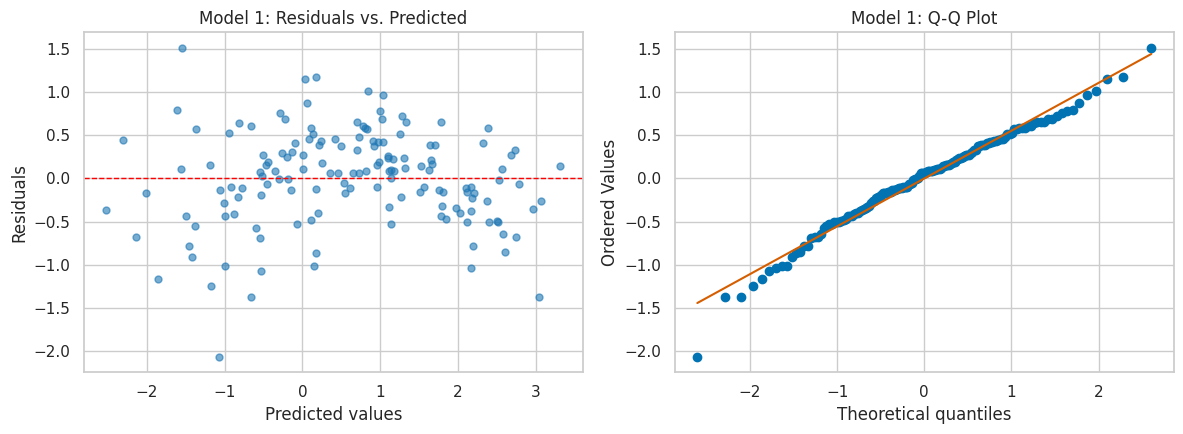

In [30]:
# Diagnostics

print("=== Serial correlation ===")
print(f"Durbin-Watson (model 2): {durbin_watson(model2.resid):.3f}")
print("A value far from 2 indicates strong serial correlation - expected in an annual panel.")
print("This is exactly why we use country-clustered standard errors in all models:")
print("They are robust to both within-country serial correlation and heteroskedasticity.\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(model1.fittedvalues, model1.resid, alpha=0.6, s=25, color="#1f77b4")
axes[0].axhline(0, color="red", lw=1, ls="--")
axes[0].set(xlabel="Predicted values", ylabel="Residuals", title="Model 1: Residuals vs. Predicted")
stats.probplot(model1.resid, dist="norm", plot=axes[1])
axes[1].set_title("Model 1: Q-Q Plot")
plt.tight_layout()
plt.show()

# STAGE 3 - NATIONAL ENERGY PROFILES (CLUSTERING)

In [31]:
# Clustering variables
# low_carbon_elec_pct is left out on purpose: check [2] showed it equals 100 minus
# fossil_share, that is the same axis. Keeping both would double its weight in KMeans.
CLUSTER_VARS = ["co2_per_capita_static_t", "fossil_share_of_elec_pct", "gdp_per_capita_usd",
                "energy_intensity", "energy_consumption_per_capita_kwh"]

work = df[df["year"] == SNAPSHOT_YEAR].dropna(subset=CLUSTER_VARS).copy()
work = work[(work[CLUSTER_VARS] > 0).all(axis=1)]

X = pd.DataFrame({
    "log_co2_pc":           np.log(work["co2_per_capita_static_t"]),
    "fossil_share_elec":    work["fossil_share_of_elec_pct"],
    "log_gdp_pc":           np.log(work["gdp_per_capita_usd"]),
    "log_energy_intensity": np.log(work["energy_intensity"]),
    "log_energy_pc":        np.log(work["energy_consumption_per_capita_kwh"]),
}, index=work.index)

scaler = StandardScaler().fit(X)          # standardisation is required: KMeans is scale sensitive
Xs = scaler.transform(X)
print(f"{len(X)} Countries, {X.shape[1]} Variables")

144 Countries, 5 Variables


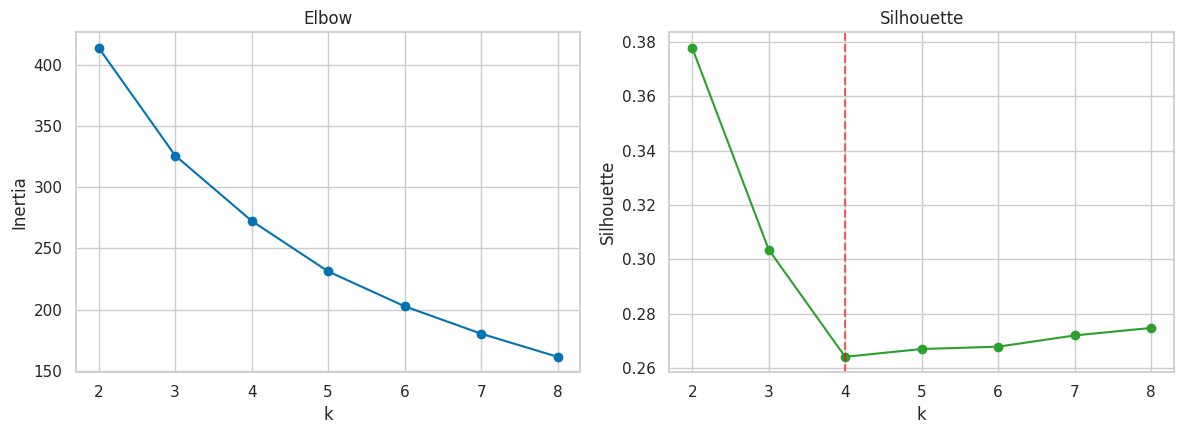

 k  silhouette  inertia
 2       0.378    413.9
 3       0.304    325.9
 4       0.264    272.5
 5       0.267    231.2
 6       0.268    202.7
 7       0.272    180.3
 8       0.275    161.4


In [32]:
# Choosing the number of clusters
k_values = list(range(2, 9))
inertia = []
silhouette = []

for k in k_values:
    km_k = KMeans(k, n_init=25, random_state=SEED).fit(Xs)
    inertia.append(km_k.inertia_)
    silhouette.append(silhouette_score(Xs, km_k.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_values, inertia, marker="o")
axes[0].set(xlabel="k", ylabel="Inertia", title="Elbow")
axes[1].plot(k_values, silhouette, marker="o", color="#2ca02c")
axes[1].axvline(N_CLUSTERS, ls="--", color="red", alpha=0.6)
axes[1].set(xlabel="k", ylabel="Silhouette", title="Silhouette")
plt.tight_layout()
save_fig("k_selection")
plt.show()

print(pd.DataFrame({"k": k_values,
                    "silhouette": np.round(silhouette, 3),
                    "inertia": np.round(inertia, 1)}).to_string(index=False))

In [33]:
# Clustering, stable numbering and data-driven names
km = KMeans(N_CLUSTERS, n_init=25, random_state=SEED).fit(Xs)
work["cluster_raw"] = km.labels_

# KMeans labels are arbitrary. Renumbering the clusters by median emissions,
# so that cluster 0 is always the cleanest one.
order = work.groupby("cluster_raw")["co2_per_capita_static_t"].median().sort_values().index
relabel = {}
for new_number, old_label in enumerate(order):
    relabel[old_label] = new_number
work["cluster"] = work["cluster_raw"].map(relabel)

# Names derived from the data, not hard-coded
profile = work.groupby("cluster")[CLUSTER_VARS].median()
gdp_med = work["gdp_per_capita_usd"].median()
fos_med = work["fossil_share_of_elec_pct"].median()

cluster_names = {}
for c, row in profile.iterrows():
    if row["gdp_per_capita_usd"] >= gdp_med:
        wealth = "developed"
    else:
        wealth = "developing"
    if row["fossil_share_of_elec_pct"] >= fos_med:
        grid = "fossil-dependent"
    else:
        grid = "low-carbon electricity"
    cluster_names[c] = f"{wealth} / {grid}"

print("=== Cluster Profile (Medians) ===")
print(profile.round(1).to_string())
print()
for c, name in cluster_names.items():
    n_in_cluster = (work["cluster"] == c).sum()
    print(f"Cluster {c}: {name}  ({n_in_cluster} Countries)")

=== Cluster Profile (Medians) ===
         co2_per_capita_static_t  fossil_share_of_elec_pct  gdp_per_capita_usd  energy_intensity  energy_consumption_per_capita_kwh
cluster                                                                                                                            
0                            0.2                      40.5               772.8               5.7                              934.5
1                            0.9                      74.7              2820.3               3.7                             4973.6
2                            4.0                      32.9             18530.3               3.0                            28299.9
3                            6.3                      92.5             10561.6               4.5                            26602.8

Cluster 0: developing / low-carbon electricity  (24 Countries)
Cluster 1: developing / fossil-dependent  (37 Countries)
Cluster 2: developed / low-carbon electricity  (42 Co

In [34]:
# Cluster against continent - does geography predict the profile?
cross = pd.crosstab(work["continent"], work["cluster"])
cross.columns = [f"{c}: {cluster_names[c]}" for c in cross.columns]
print("=== Cluster by continent ===")
print(cross.to_string())
print(f"\nEach cluster appears in {(cross > 0).sum().min()}-{(cross > 0).sum().max()} continents.")
print("So the profile is not simply a matter of geography.")

=== Cluster by continent ===
               0: developing / low-carbon electricity  1: developing / fossil-dependent  2: developed / low-carbon electricity  3: developed / fossil-dependent
continent                                                                                                                                                      
Africa                                             22                                14                                      3                                4
Asia                                                1                                 9                                      2                               17
Europe                                              0                                 0                                     25                                9
North America                                       1                                 8                                      3                                7
Oceania    

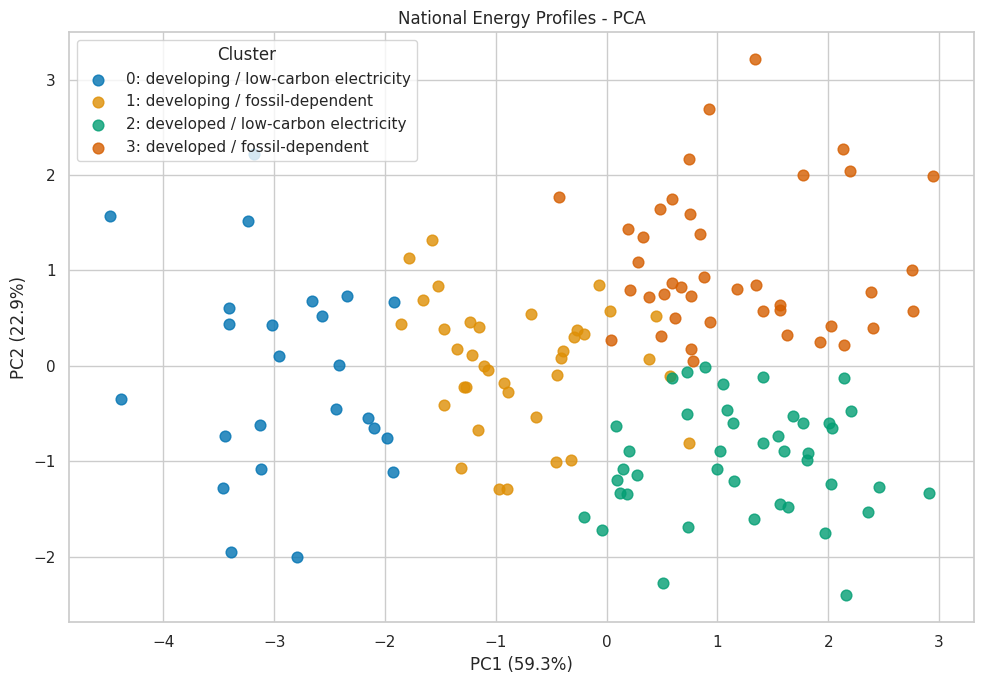

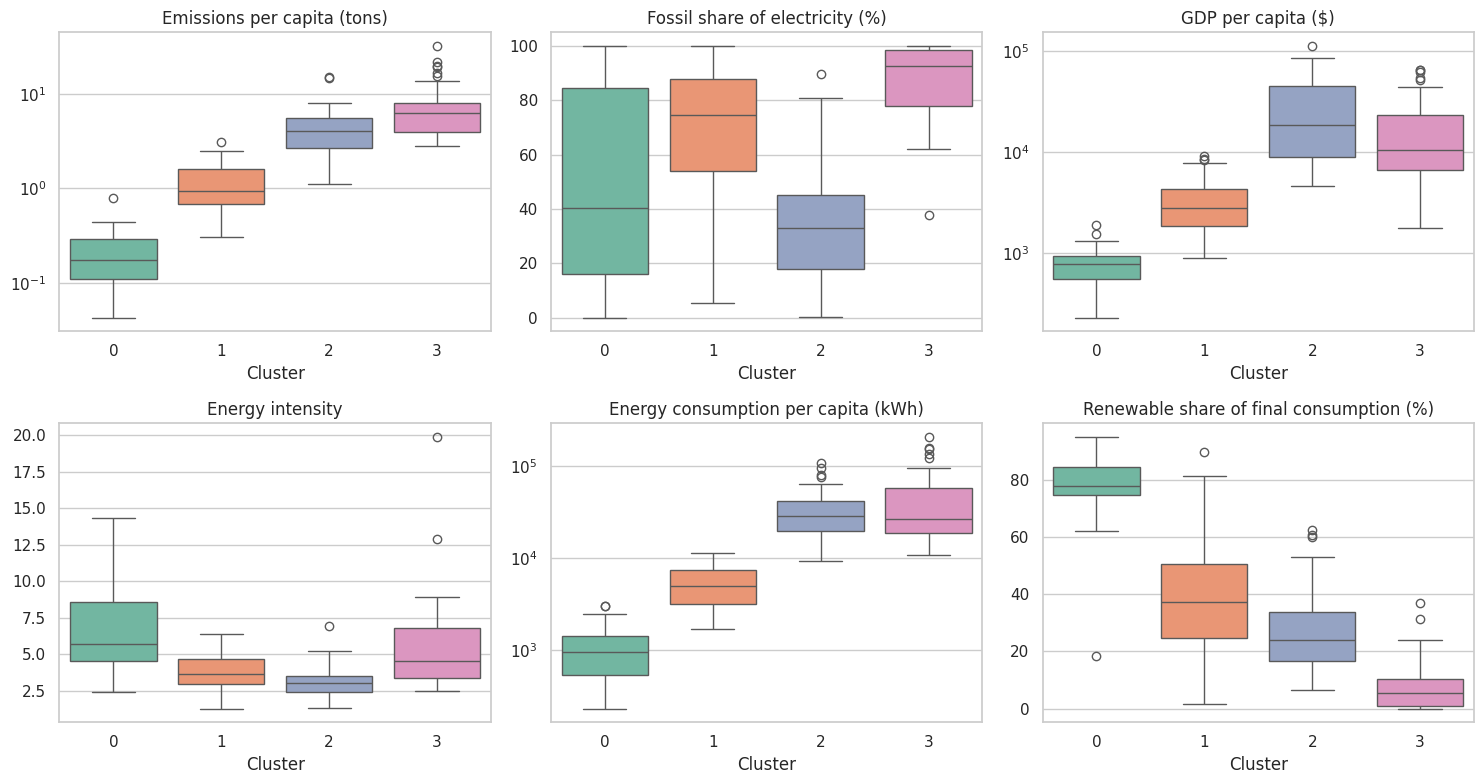

In [35]:
# Visualisation: PCA projection and the variable profiles
pca    = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(Xs)

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(cluster_names):
    sel = (work["cluster"] == c).values
    ax.scatter(coords[sel, 0], coords[sel, 1], s=60, alpha=0.8, label=f"{c}: {cluster_names[c]}")
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
       title="National Energy Profiles - PCA")
ax.legend(title="Cluster")
plt.tight_layout()
save_fig("pca_clusters")
plt.show()

plot_vars = [("co2_per_capita_static_t", "Emissions per capita (tons)"),
             ("fossil_share_of_elec_pct", "Fossil share of electricity (%)"),
             ("gdp_per_capita_usd", "GDP per capita ($)"),
             ("energy_intensity", "Energy intensity"),
             ("energy_consumption_per_capita_kwh", "Energy consumption per capita (kWh)"),
             ("renewable_share_pct", "Renewable share of final consumption (%)")]

# These three variables are strongly right-skewed, so they are drawn on a log scale.
LOG_SCALE = ["co2_per_capita_static_t", "gdp_per_capita_usd", "energy_consumption_per_capita_kwh"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (var, label) in zip(axes.ravel(), plot_vars):
    sns.boxplot(data=work, x="cluster", y=var, hue="cluster", palette="Set2", legend=False, ax=ax)
    if var in LOG_SCALE:
        ax.set_yscale("log")
    ax.set(xlabel="Cluster", ylabel="", title=label)
plt.tight_layout()
save_fig("cluster_profiles")
plt.show()

In [36]:
# List of the countries in each cluster
for c in sorted(cluster_names):
    names = sorted(work.loc[work["cluster"] == c, "country"])
    print(f"\nCluster {c} - {cluster_names[c]} ({len(names)} Countries):")
    print(", ".join(names))


Cluster 0 - developing / low-carbon electricity (24 Countries):
Afghanistan, Burkina Faso, Burundi, Cameroon, Chad, Ethiopia, Guinea, Guinea-Bissau, Haiti, Kenya, Liberia, Madagascar, Malawi, Mali, Mozambique, Niger, Rwanda, Sierra Leone, Somalia, Sudan, Togo, Uganda, Zambia, Zimbabwe

Cluster 1 - developing / fossil-dependent (37 Countries):
Angola, Bangladesh, Belize, Benin, Botswana, Cambodia, Comoros, Cuba, Djibouti, Dominica, Dominican Republic, El Salvador, Eswatini, Gabon, Ghana, Guatemala, Honduras, India, Jordan, Kiribati, Mauritania, Morocco, Myanmar, Nicaragua, Nigeria, Pakistan, Papua New Guinea, Philippines, Samoa, Sao Tome and Principe, Senegal, Solomon Islands, Sri Lanka, Tajikistan, Tonga, Tunisia, Vanuatu

Cluster 2 - developed / low-carbon electricity (42 Countries):
Armenia, Austria, Belgium, Brazil, Bulgaria, Canada, Colombia, Costa Rica, Croatia, Denmark, Ecuador, Equatorial Guinea, Fiji, Finland, France, Georgia, Germany, Greece, Hungary, Ireland, Italy, Latvia, 

In [37]:
# Empirical target: the "cluster elite"
# The target is not arbitrary. It is taken from the top 20% of countries in the same cluster
# by GDP per ton of carbon, that is what similar countries have already achieved.
best_in_class = {}
for c in sorted(cluster_names):
    sub = work[work["cluster"] == c].copy()
    sub["gdp_per_ton"] = sub["gdp_per_capita_usd"] / sub["co2_per_capita_static_t"]

    n_top = max(1, int(len(sub) * 0.2))
    top = sub.sort_values("gdp_per_ton", ascending=False).head(n_top)

    best_in_class[c] = {
        "target_co2":   top["co2_per_capita_static_t"].mean(),
        "target_clean": 100 - top["fossil_share_of_elec_pct"].mean(),
        "exemplars":    ", ".join(sorted(top["country"])[:5]),
    }

print("=== Elite Targets by Cluster ===")
for c, t in best_in_class.items():
    print(f"Cluster {c} ({cluster_names[c]}):")
    print(f" Emissions Target: {t['target_co2']:.2f} tons/capita | Clean Electricity: {t['target_clean']:.1f}%")
    print(f" Leading: {t['exemplars']}")

=== Elite Targets by Cluster ===
Cluster 0 (developing / low-carbon electricity):
 Emissions Target: 0.08 tons/capita | Clean Electricity: 59.5%
 Leading: Malawi, Rwanda, Somalia, Uganda
Cluster 1 (developing / fossil-dependent):
 Emissions Target: 0.86 tons/capita | Clean Electricity: 28.3%
 Leading: Comoros, Cuba, Djibouti, Eswatini, Guatemala
Cluster 2 (developed / low-carbon electricity):
 Emissions Target: 4.54 tons/capita | Clean Electricity: 80.1%
 Leading: Denmark, France, Ireland, Norway, Sweden
Cluster 3 (developed / fossil-dependent):
 Emissions Target: 7.17 tons/capita | Clean Electricity: 13.2%
 Leading: Barbados, Cyprus, Grenada, Israel, Japan


In [38]:
# Policy simulator
# BETA is taken from the model and not hard-coded. Model 2 (fixed effects) is the right one:
# it measures what happens when a given country changes its own mix, exactly the simulator question.
# The cross-sectional estimate (Model 1) is larger, but it also reflects fixed differences between countries.
BETA_CLEAN = model2.params["renewables_share_of_elec_pct"]
cluster_co2 = work.groupby("cluster")["co2_per_capita_static_t"].median()

print(f"BETA_CLEAN = {BETA_CLEAN:.5f} (model 2, within)")
print(f"For comparison, cross-sectional estimate (model 1): {model1.params['renewables_share_of_elec_pct']:.5f}")

def policy_advisor(country_name):
    row = work[work["country"] == country_name]
    if row.empty:
        print(f"'{country_name}' is not in the clustering sample.")
        return

    idx    = row.index[0]
    c0     = int(row["cluster"].iloc[0])
    fossil = float(row["fossil_share_of_elec_pct"].iloc[0])
    co2    = float(row["co2_per_capita_static_t"].iloc[0])
    target = best_in_class[c0]["target_co2"]

    print("\n" + "=" * 72)
    print(f"Policy recommendation: {country_name}")
    print(f"Current profile: Cluster {c0} - {cluster_names[c0]}")
    print(f"Status: {100 - fossil:.1f}% clean electricity | {co2:.2f} tons CO2 per capita")
    print("-" * 72)

    # A. Gap against the elite target
    print(f"[A] Cluster elite target: {target:.2f} tons/capita")
    if co2 > target:
        # Delta log(co2) = BETA * shift  =>  shift = (ln(target) - ln(co2)) / BETA
        need = (np.log(target) - np.log(co2)) / BETA_CLEAN
        print(f" Gap: {co2 - target:+.2f} tons. A shift of {min(need, fossil):.1f}% of the grid is required.")
        if need > fossil:
            print(" That is more than the existing fossil share, so the mix alone cannot close the gap.")
    else:
        print(" The country already meets the elite target of its cluster.")

    # B. Search for the smallest shift that moves the country to a better profile
    print("\n[B] Minimum shift that moves the country to a better profile:")
    found_shift = None
    found_cluster = None
    for shift in range(1, int(fossil) + 1):
        sim = X.loc[[idx]].copy()                       # one row, still a DataFrame
        sim["fossil_share_elec"] = fossil - shift
        sim["log_co2_pc"]        = np.log(co2) + BETA_CLEAN * shift
        new_c = relabel[km.predict(scaler.transform(sim))[0]]
        # "Better" means the new cluster is cleaner. Without this the loop could report a worse profile.
        if new_c != c0 and cluster_co2[new_c] < cluster_co2[c0]:
            found_shift = shift
            found_cluster = new_c
            break

    if found_shift is not None:
        print(f" Shift {found_shift}% of the grid from fossil to clean")
        print(f" New profile: cluster {found_cluster} - {cluster_names[found_cluster]}")
        print(f" Predicted emissions: {co2 * np.exp(BETA_CLEAN * found_shift):.2f} tons/capita")
    else:
        print(" Even a complete removal of fossil fuels does not change the profile.")
        print(" Meaning: the barrier is not the production mix but energy intensity or the level of consumption.")
    print("=" * 72)

BETA_CLEAN = -0.00528 (model 2, within)
For comparison, cross-sectional estimate (model 1): -0.00871


In [39]:
# Example run: countries from the four clusters + Israel
for country in ["Israel", "Poland", "France", "India", "Ethiopia"]:
    policy_advisor(country)


Policy recommendation: Israel
Current profile: Cluster 3 - developed / fossil-dependent
Status: 4.0% clean electricity | 7.54 tons CO2 per capita
------------------------------------------------------------------------
[A] Cluster elite target: 7.17 tons/capita
 Gap: +0.37 tons. A shift of 9.5% of the grid is required.

[B] Minimum shift that moves the country to a better profile:
 Shift 18% of the grid from fossil to clean
 New profile: cluster 2 - developed / low-carbon electricity
 Predicted emissions: 6.86 tons/capita

Policy recommendation: Poland
Current profile: Cluster 3 - developed / fossil-dependent
Status: 15.6% clean electricity | 7.61 tons CO2 per capita
------------------------------------------------------------------------
[A] Cluster elite target: 7.17 tons/capita
 Gap: +0.44 tons. A shift of 11.2% of the grid is required.

[B] Minimum shift that moves the country to a better profile:
 Shift 22% of the grid from fossil to clean
 New profile: cluster 2 - developed / lo

In [40]:
!zip -r /content/figures.zip /content/figures
from google.colab import files
files.download("/content/figures.zip")

  adding: content/figures/ (stored 0%)
  adding: content/figures/v2_emissions.png (deflated 15%)
  adding: content/figures/v6_correlation_heatmap.png (deflated 8%)
  adding: content/figures/v4_v5_rankings.png (deflated 21%)
  adding: content/figures/pca_clusters.png (deflated 16%)
  adding: content/figures/v7_gdp_vs_renewable.png (deflated 8%)
  adding: content/figures/k_selection.png (deflated 13%)
  adding: content/figures/v1_generation_mix.png (deflated 13%)
  adding: content/figures/cluster_profiles.png (deflated 22%)
  adding: content/figures/v3_renewable_by_continent.png (deflated 16%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>